# Анализ рынка аренды жилья в Индии: от чего зависит арендная плата

**Команда №** [ВПИШИТЕ НОМЕР КОМАНДЫ]

**Участники:**
| № | Фамилия Имя | Номер группы |
|---|---|---|
| 1 | [ВПИШИТЕ] | [ВПИШИТЕ] |
| 2 | [ВПИШИТЕ] | [ВПИШИТЕ] |
| 3 | [ВПИШИТЕ] | [ВПИШИТЕ] |

## Описание данных

**Тема датасета:** объявления об аренде домов, квартир и апартаментов в шести крупнейших городах Индии (Bangalore, Chennai, Delhi, Hyderabad, Kolkata, Mumbai).

**Наблюдение:** одно объявление об аренде жилья.

**Источник данных:** Kaggle, *House Rent Prediction Dataset* (автор Sourav Banerjee), https://kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset. Объявления размещены в период с 13.04.2022 по 11.07.2022.

**Объём данных:** 4746 наблюдений и 12 признаков (в ходе работы будут добавлены ещё 2 признака, выделенные из `Floor`).

**Целевой признак:** `Rent` - ежемесячная арендная плата (в индийских рупиях).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [2]:
df = pd.read_csv('House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,5/13/2022,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,5/16/2022,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,7/4/2022,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,5/9/2022,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
print('Количество наблюдений:', df.shape[0])
print('Количество признаков:', df.shape[1])
print('Период объявлений:', pd.to_datetime(df['Posted On']).min().date(), '-', pd.to_datetime(df['Posted On']).max().date())

Количество наблюдений: 4746
Количество признаков: 12
Период объявлений: 2022-04-13 - 2022-07-11


## Описание признаков

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [5]:
print(df.dtypes)
print()
print('Число уникальных значений:')
print(df.nunique())

Posted On              str
BHK                  int64
Rent                 int64
Size                 int64
Floor                  str
Area Type              str
Area Locality          str
City                   str
Furnishing Status      str
Tenant Preferred       str
Bathroom             int64
Point of Contact       str
dtype: object

Число уникальных значений:
Posted On              81
BHK                     6
Rent                  243
Size                  615
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64


Формат указан как в `pandas` (`object` - строка; в новых версиях pandas такие столбцы отображаются как `str`).

| Признак | Описание | Формат | Тип данных |
|---|---|---|---|
| Posted On | Дата размещения объявления | object | Дата / время |
| BHK | Количество спален (Bedroom, Hall, Kitchen) | int64 | Количественный дискретный |
| **Rent** | **Ежемесячная арендная плата, ₹ (целевой признак)** | int64 | Количественный непрерывный |
| Size | Площадь жилья, кв. футы | int64 | Количественный непрерывный |
| Floor | Этаж и общее число этажей в доме (например, «3 out of 5») | object | Категориальный (составной текстовый) |
| Area Type | Способ расчёта площади: Super Area, Carpet Area, Built Area | object | Категориальный номинальный |
| Area Locality | Район / локация жилья | object | Категориальный номинальный |
| City | Город | object | Категориальный номинальный |
| Furnishing Status | Меблировка: Unfurnished < Semi-Furnished < Furnished | object | Категориальный порядковый |
| Tenant Preferred | Предпочитаемый тип арендатора: Bachelors, Family, Bachelors/Family | object | Категориальный номинальный |
| Bathroom | Количество ванных комнат | int64 | Количественный дискретный |
| Point of Contact | Контакт для связи: Contact Owner, Contact Agent, Contact Builder | object | Категориальный номинальный |
| floor_num *(новый)* | Этаж квартиры (Ground = 0, Upper Basement = -1, Lower Basement = -2) | int64 | Количественный дискретный |
| total_floors *(новый)* | Общее количество этажей в здании | int64 | Количественный дискретный |

Бинарных признаков в исходных данных нет: все категориальные признаки имеют 3 и более категорий (`City` - 6, `Area Locality` - 2235).

## Новые признаки

In [6]:
# Признак Floor имеет вид "3 out of 5" (этаж из общего числа этажей) - разбиваем на два числовых признака
def parse_floor(s):
    s = str(s).strip()
    if ' out of ' in s:
        cur, tot = s.split(' out of ')
    else:
        cur, tot = s, None
    special = {'Ground': 0, 'Upper Basement': -1, 'Lower Basement': -2}
    cur_num = special[cur] if cur in special else int(cur)
    tot_num = int(tot) if tot is not None else np.nan
    return pd.Series([cur_num, tot_num])

df[['floor_num', 'total_floors']] = df['Floor'].apply(parse_floor)
df[['Floor', 'floor_num', 'total_floors']].head(8)

,Floor,floor_num,total_floors
0,Ground out of 2,0.000,2.000
1,1 out of 3,1.000,3.000
2,1 out of 3,1.000,3.000
3,1 out of 2,1.000,2.000
4,1 out of 2,1.000,2.000
5,Ground out of 1,0.000,1.000
6,Ground out of 4,0.000,4.000
7,1 out of 2,1.000,2.000


In [7]:
df[['floor_num', 'total_floors']].dtypes

floor_num       float64
total_floors    float64
dtype: object

Признак `Floor` содержит два вида информации (этаж и этажность дома), поэтому он разделён на два числовых признака: `floor_num` и `total_floors`. Для «Ground» принято значение 0, для подвальных этажей - отрицательные значения. В четырёх объявлениях указан только этаж без этажности дома - для `total_floors` там возникли пропуски (они обрабатываются в следующем разделе). Исходный текстовый `Floor` далее в анализе не используется.

## Пропуски и дубликаты

In [8]:
print('Пропуски по признакам (исходные + новые):')
print(df.isna().sum())
print('\nПолных дубликатов:', df.duplicated().sum())

Пропуски по признакам (исходные + новые):
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
floor_num            0
total_floors         4
dtype: int64

Полных дубликатов: 0


In [9]:
df_clean = df.copy()

quant_cols = ['BHK', 'Size', 'Bathroom', 'floor_num', 'total_floors']   # количественные предикторы
cat_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']

# Количественные признаки с пропусками -> медиана (устойчива к выбросам и скошенности)
for col in quant_cols + ['Rent']:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean[['floor_num', 'total_floors']] = df_clean[['floor_num', 'total_floors']].astype(int)

# Категориальные признаки с пропусками -> мода
for col in cat_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Полные дубликаты -> удаляем
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print('Пропусков после обработки:', df_clean.isna().sum().sum())
print('Дубликатов после обработки:', df_clean.duplicated().sum())
print(f'Строк: было {n_before}, стало {len(df_clean)}')

Пропусков после обработки: 0
Дубликатов после обработки: 0
Строк: было 4746, стало 4746


- В исходных 12 признаках пропусков нет. Пропуски (4 шт.) появились только в новом признаке `total_floors`.
- Пропуски в `total_floors` заменены **медианой** (4 этажа): признак дискретный и сильно скошен вправо, поэтому медиана - более подходящая мера центральной тенденции, чем среднее.
- Полных дубликатов в данных нет, поэтому ни одна строка не удалена.
- Очищенный датафрейм сохранён в переменную `df_clean` (4746 строк). Дальше работа ведётся только с ним.

## Выбросы

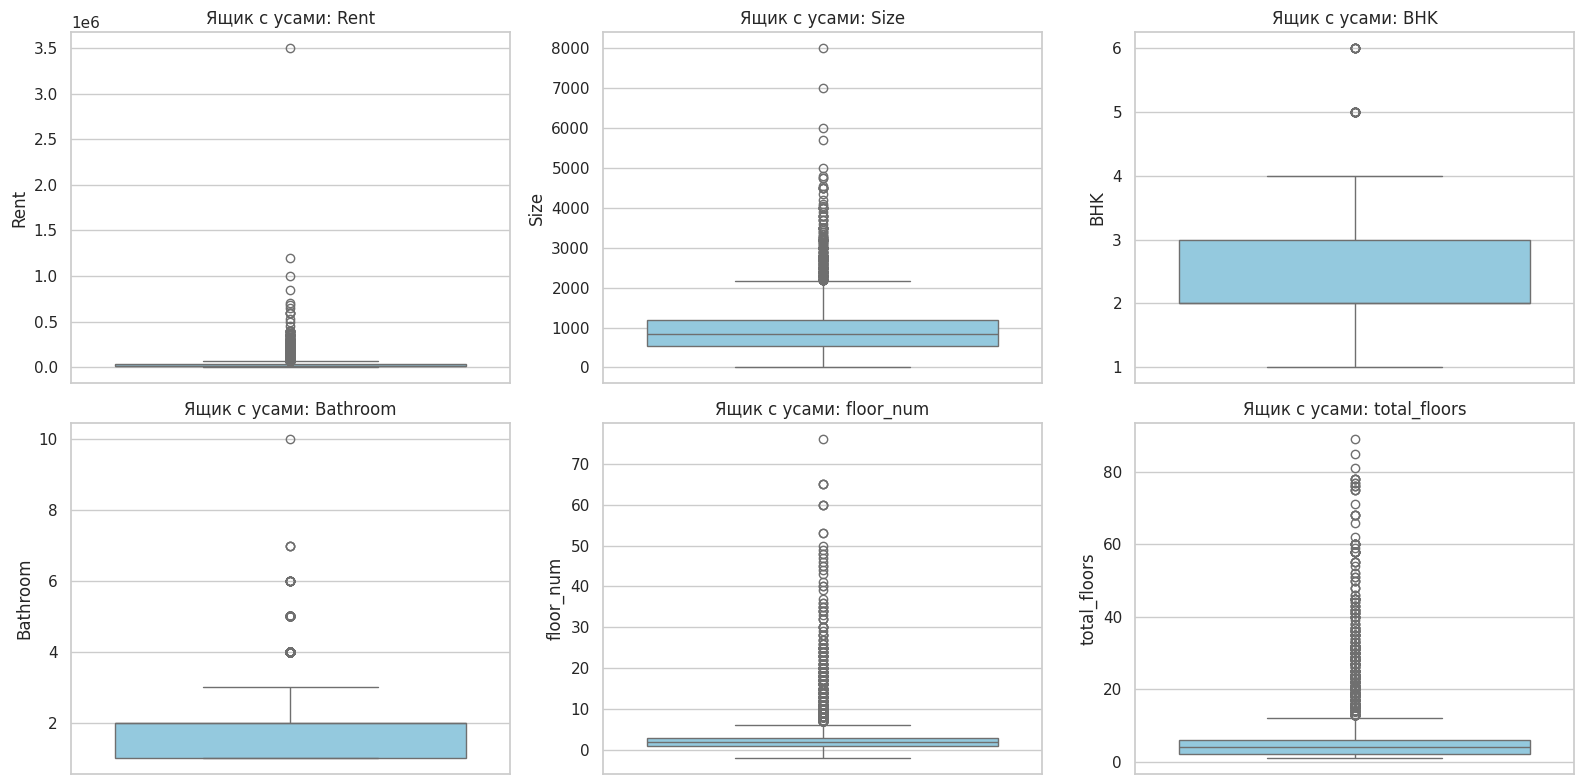

In [10]:
box_cols = ['Rent', 'Size', 'BHK', 'Bathroom', 'floor_num', 'total_floors']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), box_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='skyblue')
    ax.set_title(f'Ящик с усами: {col}')
plt.tight_layout()
plt.show()

In [11]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

rows = []
for col in box_cols:
    lo, hi = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    rows.append([col, lo, hi, n_out, n_out / len(df_clean) * 100])
pd.DataFrame(rows, columns=['Признак', 'Нижняя граница', 'Верхняя граница', 'Число выбросов', 'Доля, %'])

,Признак,Нижняя граница,Верхняя граница,Число выбросов,"Доля, %"
0,Rent,"-24,500.000","67,500.000",520,10.957
1,Size,-425.000,"2,175.000",203,4.277
2,BHK,0.500,4.500,27,0.569
3,Bathroom,-0.500,3.500,232,4.888
4,floor_num,-2.000,6.000,638,13.443
5,total_floors,-4.000,12.000,704,14.834


**Выводы по ящикам с усами:**
- Больше всего выбросов у `total_floors` (704, 14.8%), `floor_num` (638, 13.4%) и `Rent` (520, 11.0%): у арендной платы есть очень длинный правый «хвост» (максимум - 3,5 млн ₹ при медиане около 16 тыс. ₹).
- У `Size` 203 выброса (4.3%), у `Bathroom` - 232 (4.9%), у `BHK` - 27 (0.6%).
- Высокие значения `floor_num` и `total_floors` - это реальные высотные дома (в основном крупные города), а не ошибки, поэтому по ним выбросы не удаляются.
- Метод 1.5·IQR для `Rent` удалил бы 11% наблюдений, включая реальное дорогое жильё, поэтому для `Rent` используется более мягкий метод 3 стандартных отклонений, а метод 1.5·IQR применяется к признаку `Size`.

In [12]:
# Метод N стандартных отклонений по признаку Rent (N = 3)
N = 3
mean_rent, std_rent = df_clean['Rent'].mean(), df_clean['Rent'].std()
lower, upper = mean_rent - N * std_rent, mean_rent + N * std_rent
print(f'Границы: [{lower:,.0f}; {upper:,.0f}]')

df_sigma = df_clean[(df_clean['Rent'] >= lower) & (df_clean['Rent'] <= upper)].copy()
print(f'Строк было: {len(df_clean)}, стало: {len(df_sigma)}, удалено: {len(df_clean) - len(df_sigma)}')

Границы: [-199,326; 269,313]
Строк было: 4746, стало: 4680, удалено: 66


**Метод N стандартных отклонений** (N = 3, признак `Rent`): допустимый интервал [-199 326; 269 313]. Нижняя граница отрицательна, поэтому фактически отсекаются только слишком дорогие объявления. Удалено 66 строк (осталось 4680). Результат сохранён в `df_sigma`.

In [13]:
# Метод 1.5*IQR по признаку Size (работаем с df_sigma)
q1, q3 = df_sigma['Size'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f'Q1 = {q1}, Q3 = {q3}, IQR = {iqr}')
print(f'Границы: [{lower}; {upper}]')

df_iqr = df_sigma[(df_sigma['Size'] >= lower) & (df_sigma['Size'] <= upper)].copy()
print(f'Строк было: {len(df_sigma)}, стало: {len(df_iqr)}, удалено: {len(df_sigma) - len(df_iqr)}')

Q1 = 550.0, Q3 = 1200.0, IQR = 650.0
Границы: [-425.0; 2175.0]
Строк было: 4680, стало: 4517, удалено: 163


**Метод 1.5·IQR** (признак `Size`, работаем с `df_sigma`): Q1 = 550, Q3 = 1200, IQR = 650, допустимый интервал [-425; 2175]. Удалено 163 строки (осталось 4517). Результат сохранён в `df_iqr`; **все дальнейшие разделы выполняются на `df_iqr`**.

*Замечание:* в `Size` остаётся минимальное значение 10 кв. футов - вероятно, ошибка ввода в объявлении, но метод IQR его не считает выбросом (нижняя граница отрицательна), поэтому по условию задания оно не удаляется.

## Визуализация

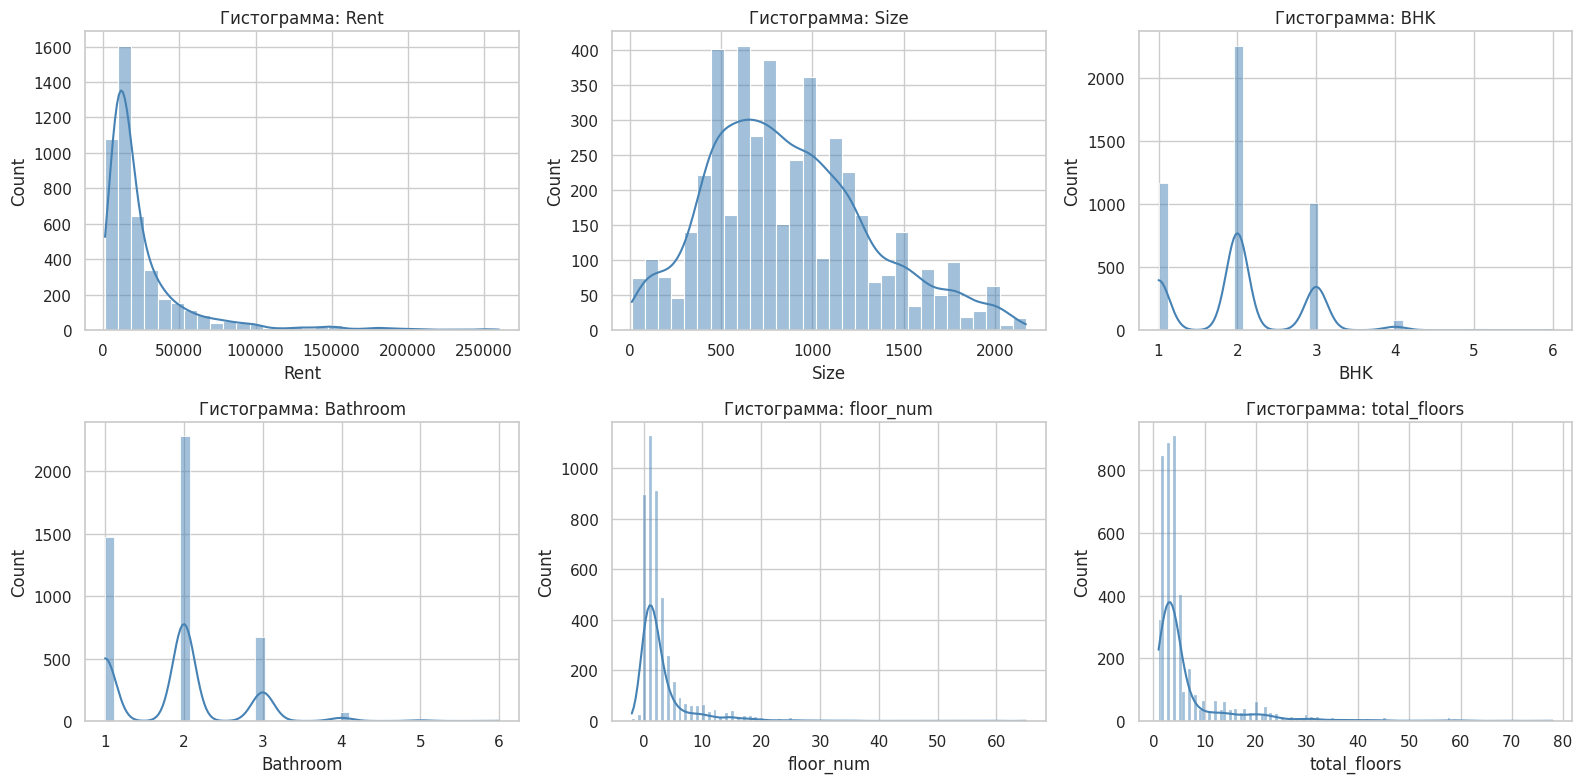

In [14]:
hist_cols = ['Rent', 'Size', 'BHK', 'Bathroom', 'floor_num', 'total_floors']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), hist_cols):
    sns.histplot(df_iqr[col], kde=True, ax=ax, color='steelblue', bins=30 if col in ['Rent', 'Size'] else 'auto')
    ax.set_title(f'Гистограмма: {col}')
plt.tight_layout()
plt.show()

**Выводы по распределению количественных признаков:**
- `Rent`: сильная правосторонняя асимметрия (асимметрия 3.39), большинство объявлений - в диапазоне 10-30 тыс. ₹, медиана (15 000) заметно ниже среднего (26 747). Распределение не похоже на нормальное.
- `Size`: унимодальное, умеренно скошено вправо (асимметрия 0.53), типичная площадь - 600-1200 кв. футов, самое частое значение - 1000.
- `BHK` и `Bathroom`: дискретные, преобладают значения 1-2 (не менее 75% объявлений), самое частое значение - 2; варианты 4-6 встречаются редко.
- `floor_num` и `total_floors`: большинство домов невысокие (медиана этажности - 4, этаж - 2), но есть длинный правый хвост (высотки до 78 этажей).

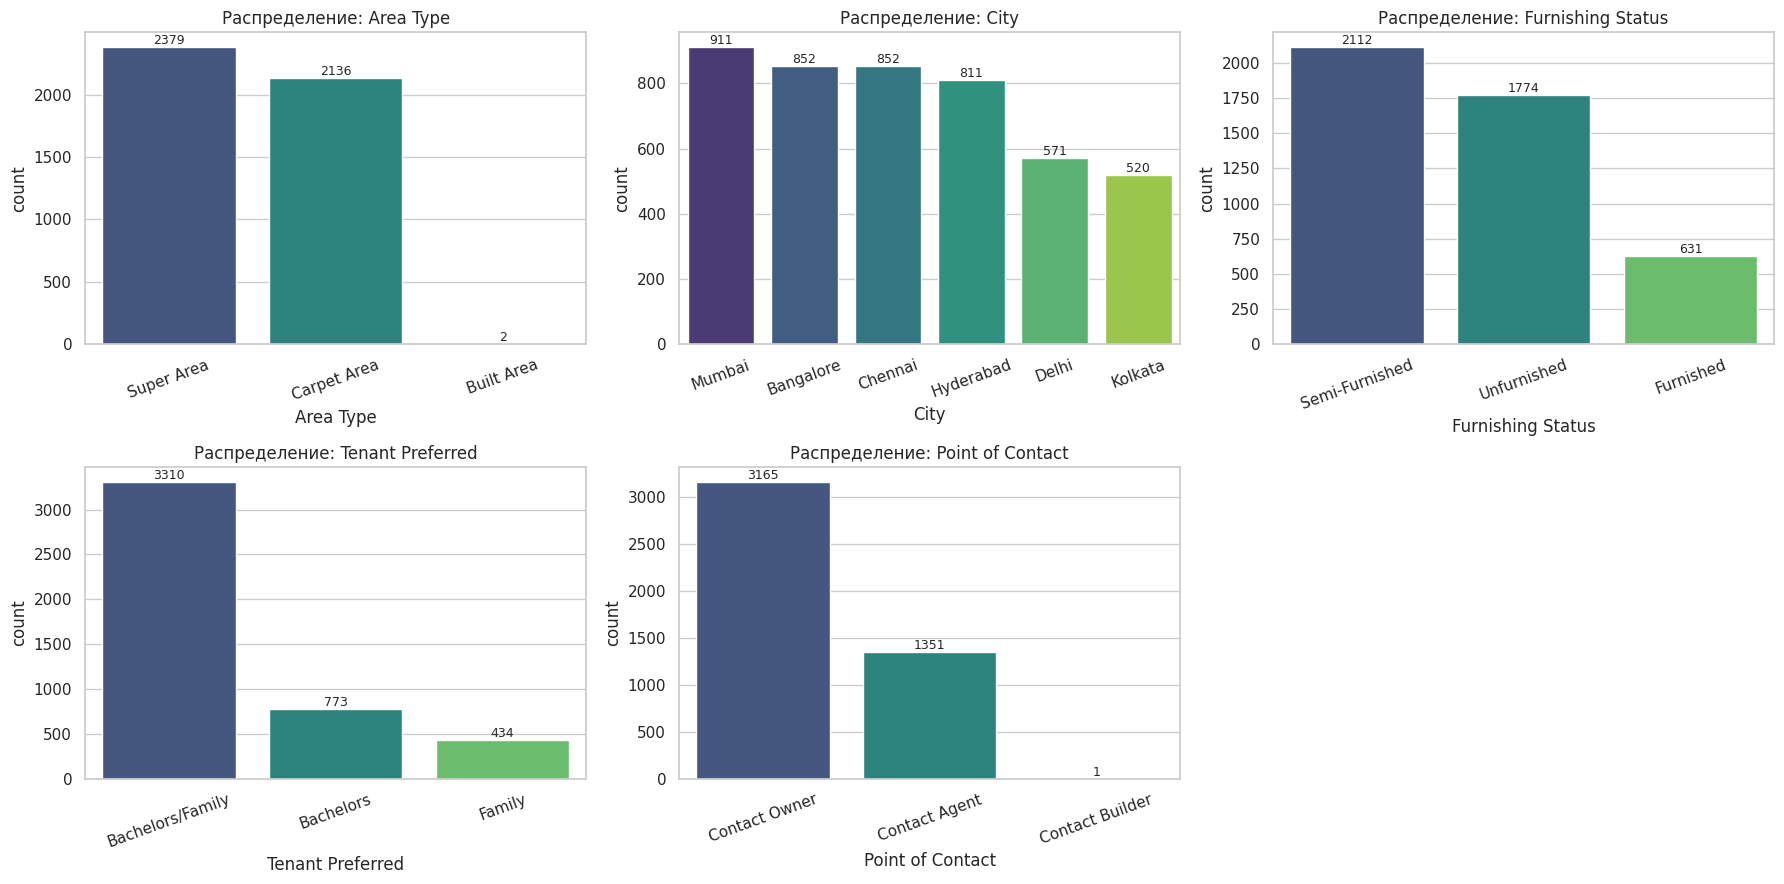

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df_iqr[col].value_counts().index
    sns.countplot(data=df_iqr, x=col, order=order, ax=ax, palette='viridis')
    ax.set_title(f'Распределение: {col}')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

**Выводы по распределению категориальных признаков:**
- `City`: больше всего объявлений в Mumbai (20.2%), меньше всего - в Kolkata (11.5%); города представлены сравнительно равномерно.
- `Furnishing Status`: чаще всего Semi-Furnished (46.8%), затем Unfurnished (39.3%); полностью меблированное жильё - только 14.0%.
- `Tenant Preferred`: в 73.3% объявлений подходят и семьи, и холостяки (Bachelors/Family).
- `Point of Contact`: 70.1% объявлений размещают собственники, 29.9% - агенты; Contact Builder встречается только 1 раз.
- `Area Type`: Super Area (52.7%) и Carpet Area (47.3%) встречаются примерно поровну; Built Area - всего 2 наблюдения (0.04%), то есть эти категории практически не несут информации.

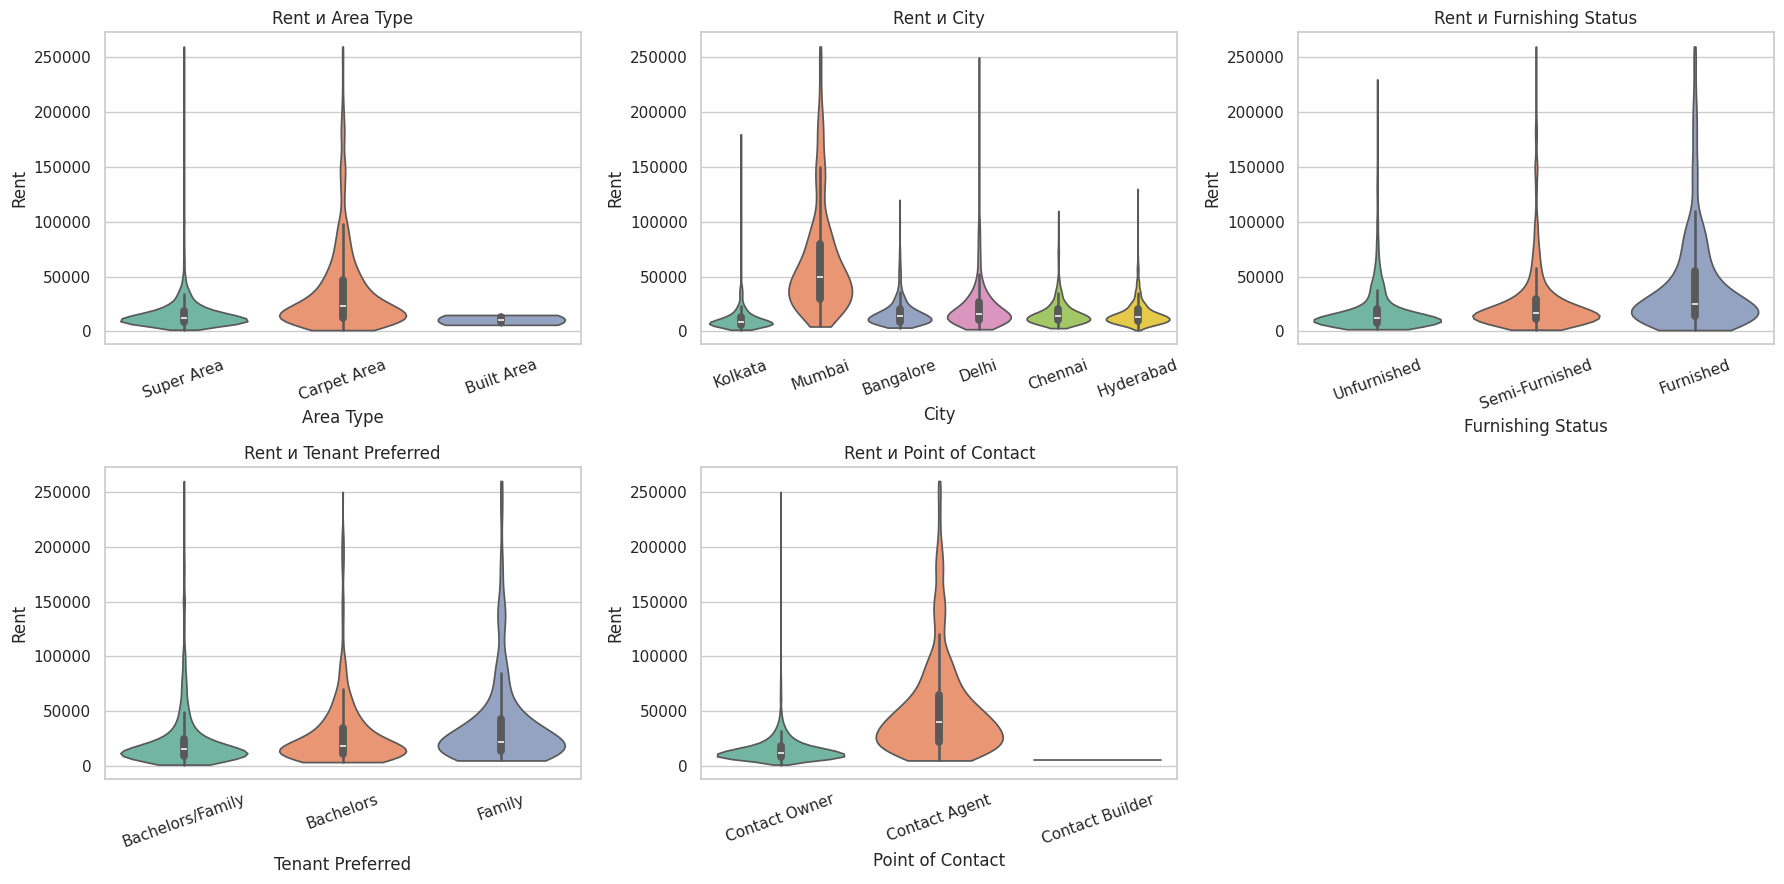

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.violinplot(data=df_iqr, x=col, y='Rent', ax=ax, palette='Set2', cut=0)
    ax.set_title(f'Rent и {col}')
    ax.tick_params(axis='x', rotation=20)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

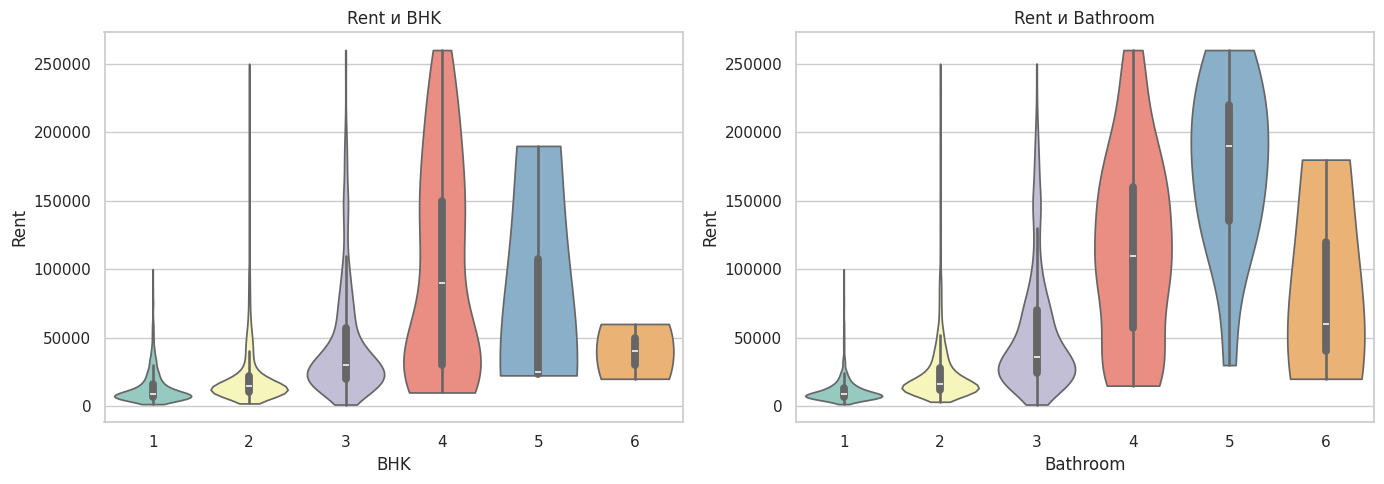

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['BHK', 'Bathroom']):
    sns.violinplot(data=df_iqr, x=col, y='Rent', ax=ax, palette='Set3', cut=0)
    ax.set_title(f'Rent и {col}')
plt.tight_layout()
plt.show()

**Выводы по скрипичным графикам:**
- `City`: аренда в Mumbai существенно выше и разбросана шире, чем в остальных городах; в Kolkata распределение самое «узкое» и низкое.
- `Furnishing Status`: чем больше мебели, тем выше центр и разброс аренды (Furnished > Semi-Furnished > Unfurnished).
- `Point of Contact`: объявления через агентов заметно дороже, чем от собственников (в среднем примерно 53 тыс. ₹ против 15 тыс. ₹).
- `Area Type` и `Tenant Preferred`: различия между категориями есть, но они менее выражены, чем у города и меблировки. Для Carpet Area аренда в среднем выше, чем для Super Area, это может быть связано с различным составом по городам.
- `BHK` и `Bathroom`: с ростом количества комнат и ванных медиана аренды растёт, а разброс увеличивается. Для редких значений (5-6 комнат) форма «скрипки» ненадёжна из-за малого числа наблюдений.

## Описательные статистики

In [18]:
r = df_iqr['Rent']
desc_rent = pd.Series({
    'Количество наблюдений': r.count(),
    'Среднее': r.mean(),
    'Медиана': r.median(),
    'Мода': r.mode()[0],
    'Стандартное отклонение': r.std(),
    'Дисперсия': r.var(),
    'Минимум': r.min(),
    'Максимум': r.max(),
    'Размах': r.max() - r.min(),
    'Q1 (25%)': r.quantile(0.25),
    'Q3 (75%)': r.quantile(0.75),
    'IQR': r.quantile(0.75) - r.quantile(0.25),
    'Коэффициент вариации, %': r.std() / r.mean() * 100,
    'Асимметрия': r.skew(),
    'Эксцесс': r.kurt()
}, name='Rent')
desc_rent.to_frame()

,Rent
Количество наблюдений,"4,517.000"
Среднее,"26,747.049"
Медиана,"15,000.000"
Мода,"15,000.000"
Стандартное отклонение,"32,611.400"
Дисперсия,"1,063,503,403.941"
Минимум,"1,200.000"
Максимум,"260,000.000"
Размах,"258,800.000"
Q1 (25%),"10,000.000"


**Интерпретация описательных статистик целевого признака `Rent`** (количественная непрерывная шкала):
- Среднее значение аренды - 26 747 ₹, медиана - 15 000 ₹: половина объявлений дешевле 15 000 ₹. Мода тоже равна 15 000 ₹.
- Среднее значительно больше медианы, а асимметрия равна 3.39 (> 0): распределение сильно скошено вправо за счёт небольшого числа дорогих объявлений.
- Эксцесс 14.07 (> 0) - «хвосты» намного тяжелее, чем у нормального распределения.
- Стандартное отклонение - 32 611 ₹ (дисперсия ≈ 1.06·10⁹ ₹²), коэффициент вариации 121.9%: разброс арендной платы очень велик и превышает среднее значение.
- Минимум - 1 200 ₹, максимум - 260 000 ₹, размах - 258 800 ₹.
- Q1 = 10 000 ₹, Q3 = 30 000 ₹, IQR = 20 000 ₹: средние 50% объявлений укладываются в диапазон от 10 до 30 тыс. ₹.

In [19]:
# Количественные предикторы
desc_q = df_iqr[quant_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew']).T
desc_q['Q1'] = df_iqr[quant_cols].quantile(0.25)
desc_q['Q3'] = df_iqr[quant_cols].quantile(0.75)
desc_q['mode'] = [df_iqr[c].mode()[0] for c in quant_cols]
desc_q

,count,mean,median,std,min,max,skew,Q1,Q3,mode
BHK,"4,517.000",2.004,2.000,0.751,1.000,6.000,0.339,1.000,2.000,2
Size,"4,517.000",872.626,800.000,441.652,10.000,"2,170.000",0.527,550.000,"1,150.000",1000
Bathroom,"4,517.000",1.868,2.000,0.750,1.000,6.000,0.734,1.000,2.000,2
floor_num,"4,517.000",3.239,2.000,5.296,-2.000,65.000,4.605,1.000,3.000,1
total_floors,"4,517.000",6.621,4.000,8.719,1.000,78.000,3.614,2.000,6.000,4


In [20]:
# Категориальные предикторы: для номинальных/порядковых шкал считаем моду и частоты (среднее и дисперсия не имеют смысла)
for col in cat_cols:
    vc = df_iqr[col].value_counts()
    t = pd.DataFrame({'Частота': vc, 'Доля, %': (vc / len(df_iqr) * 100).round(2)})
    print(f'--- {col} (мода: {df_iqr[col].mode()[0]}) ---')
    display(t)

--- Area Type (мода: Super Area) ---


,Частота,"Доля, %"
Area Type,,
Super Area,2379,52.670
Carpet Area,2136,47.290
Built Area,2,0.040


--- City (мода: Mumbai) ---


,Частота,"Доля, %"
City,,
Mumbai,911,20.170
Bangalore,852,18.860
Chennai,852,18.860
Hyderabad,811,17.950
Delhi,571,12.640
Kolkata,520,11.510


--- Furnishing Status (мода: Semi-Furnished) ---


,Частота,"Доля, %"
Furnishing Status,,
Semi-Furnished,2112,46.760
Unfurnished,1774,39.270
Furnished,631,13.970


--- Tenant Preferred (мода: Bachelors/Family) ---


,Частота,"Доля, %"
Tenant Preferred,,
Bachelors/Family,3310,73.280
Bachelors,773,17.110
Family,434,9.610


--- Point of Contact (мода: Contact Owner) ---


,Частота,"Доля, %"
Point of Contact,,
Contact Owner,3165,70.070
Contact Agent,1351,29.910
Contact Builder,1,0.020


**Интерпретация описательных статистик предикторов:**

Количественные предикторы:
- `BHK`: в среднем 2.0 комнаты, медиана и мода равны 2, стандартное отклонение 0.75; Q1 = 1, Q3 = 2. Типичное жильё - одно- или двухкомнатное.
- `Size`: среднее 873 кв. фута, медиана 800, мода 1000; стандартное отклонение 442; средние 50% объявлений - от 550 до 1150 кв. футов. Среднее > медианы, асимметрия 0.53 - небольшой правый скос.
- `Bathroom`: в среднем 1.87 ванной, медиана и мода - 2, асимметрия 0.73: чаще всего 1-2 ванные.
- `floor_num`: среднее 3.2, медиана 2, мода 1; асимметрия 4.6 - большинство квартир на нижних этажах, но есть квартиры на очень высоких этажах (до 65).
- `total_floors`: среднее 6.6, медиана 4, мода 4; асимметрия 3.6 - преобладают низкоэтажные дома, но есть небоскрёбы (до 78 этажей).

Категориальные предикторы (для номинальных и порядковых шкал считаются только мода и частоты):
- `Area Type`: мода - Super Area (52.7%).
- `City`: мода - Mumbai (20.2%).
- `Furnishing Status` (порядковый): мода - Semi-Furnished (46.8%); Furnished - 14.0%.
- `Tenant Preferred`: мода - Bachelors/Family (73.3%).
- `Point of Contact`: мода - Contact Owner (70.1%).

## Перекодирование данных

Работаем с `df_iqr` (без пропусков, дубликатов и выбросов).

- **One-Hot кодирование** (`OneHotEncoder(drop='first')`): строго бинарных категориальных признаков в данных нет (у всех 3 и более категорий), поэтому One-Hot применён к номинальным признакам `Area Type`, `Tenant Preferred`, `Point of Contact` и `City`. Первая категория каждого признака отбрасывается, чтобы избежать мультиколлинеарности.
- **LabelEncoder** применён к `City` (коды присваиваются по алфавиту). Это лишь демонстрация: у города нет естественного порядка, поэтому в корреляции и регрессию вместо него берутся One-Hot-столбцы.
- **OrdinalEncoder** применён к порядковому признаку `Furnishing Status` с явным порядком: Unfurnished = 0 < Semi-Furnished = 1 < Furnished = 2.

In [21]:
df_enc = df_iqr.copy().reset_index(drop=True)

# 1) One-Hot кодирование (drop='first', чтобы избежать мультиколлинеарности)
ohe_cols = ['Area Type', 'Tenant Preferred', 'Point of Contact', 'City']
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_arr = ohe.fit_transform(df_enc[ohe_cols])
df_ohe = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(ohe_cols), index=df_enc.index).astype(int)
print('Базовые (отброшенные) категории:', dict(zip(ohe_cols, [c[0] for c in ohe.categories_])))

# 2) LabelEncoder (для демонстрации; порядок кодов - алфавитный, поэтому для City в модель не берём)
le = LabelEncoder()
df_enc['City_label'] = le.fit_transform(df_enc['City'])
print('LabelEncoder City:', dict(zip(le.classes_, range(len(le.classes_)))))

# 3) OrdinalEncoder для порядкового признака Furnishing Status
oe = OrdinalEncoder(categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']])
df_enc['Furnishing_ord'] = oe.fit_transform(df_enc[['Furnishing Status']]).astype(int)
print('OrdinalEncoder Furnishing Status: Unfurnished=0, Semi-Furnished=1, Furnished=2')

df_model = pd.concat([df_enc[['Rent'] + quant_cols + ['Furnishing_ord']], df_ohe], axis=1)
print('\nИтоговая таблица для моделирования:', df_model.shape)
df_model.head()

Базовые (отброшенные) категории: {'Area Type': 'Built Area', 'Tenant Preferred': 'Bachelors', 'Point of Contact': 'Contact Agent', 'City': 'Bangalore'}
LabelEncoder City: {'Bangalore': 0, 'Chennai': 1, 'Delhi': 2, 'Hyderabad': 3, 'Kolkata': 4, 'Mumbai': 5}
OrdinalEncoder Furnishing Status: Unfurnished=0, Semi-Furnished=1, Furnished=2

Итоговая таблица для моделирования: (4517, 18)


,Rent,BHK,Size,Bathroom,floor_num,total_floors,Furnishing_ord,Area Type_Carpet Area,Area Type_Super Area,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,10000,2,1100,2,0,2,0,0,1,1,0,0,1,0,0,0,1,0
1,20000,2,800,1,1,3,1,0,1,1,0,0,1,0,0,0,1,0
2,17000,2,1000,1,1,3,1,0,1,1,0,0,1,0,0,0,1,0
3,10000,2,800,1,1,2,0,0,1,1,0,0,1,0,0,0,1,0
4,7500,2,850,1,1,2,0,1,0,0,0,0,1,0,0,0,1,0


Результат - таблица `df_model` (4517 строк, 18 столбцов): целевой `Rent`, 5 количественных предикторов, `Furnishing_ord` и 11 One-Hot-столбцов. Признаки `Posted On` и `Area Locality` исключены (дата не используется в анализе, а у локации 2235 уникальных значений, то есть почти каждое наблюдение - своя категория).

## Корреляционный анализ

Пирсон:   r = 0.356, p-value = 4.27e-135
Спирмен: rho = 0.460, p-value = 6.97e-236


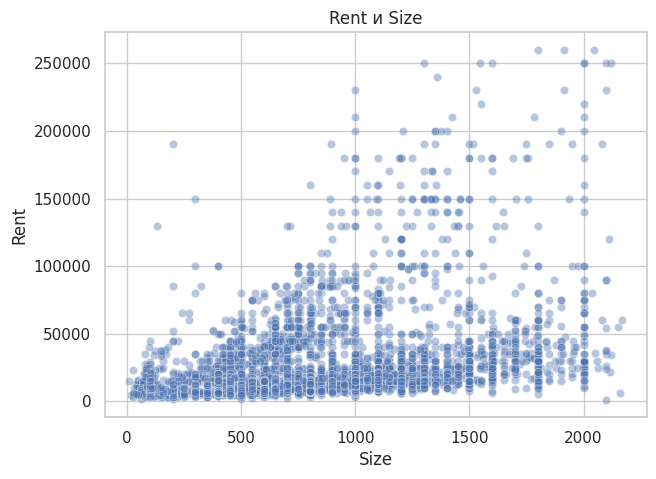

In [22]:
# Парная корреляция: Rent и Size
pear_r, pear_p = stats.pearsonr(df_model['Size'], df_model['Rent'])
spear_r, spear_p = stats.spearmanr(df_model['Size'], df_model['Rent'])
print(f'Пирсон:   r = {pear_r:.3f}, p-value = {pear_p:.2e}')
print(f'Спирмен: rho = {spear_r:.3f}, p-value = {spear_p:.2e}')

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_model, x='Size', y='Rent', alpha=0.4)
plt.title('Rent и Size')
plt.show()

**Интерпретация корреляции между `Rent` и `Size`:**
- Коэффициент Пирсона r = 0.356: положительная линейная связь умеренной силы (чем больше площадь, тем выше аренда).
- Коэффициент Спирмена ρ = 0.460: монотонная связь умеренной силы, она сильнее линейной. Это объясняется скошенностью `Rent`, выбросами и нелинейностью зависимости: Пирсон на них чувствительнее.
- p-value в обоих случаях практически равно 0 (< 0.05): связь статистически значима.
- Корреляция не означает причинность: значительную часть различий в аренде объясняют город и другие факторы.

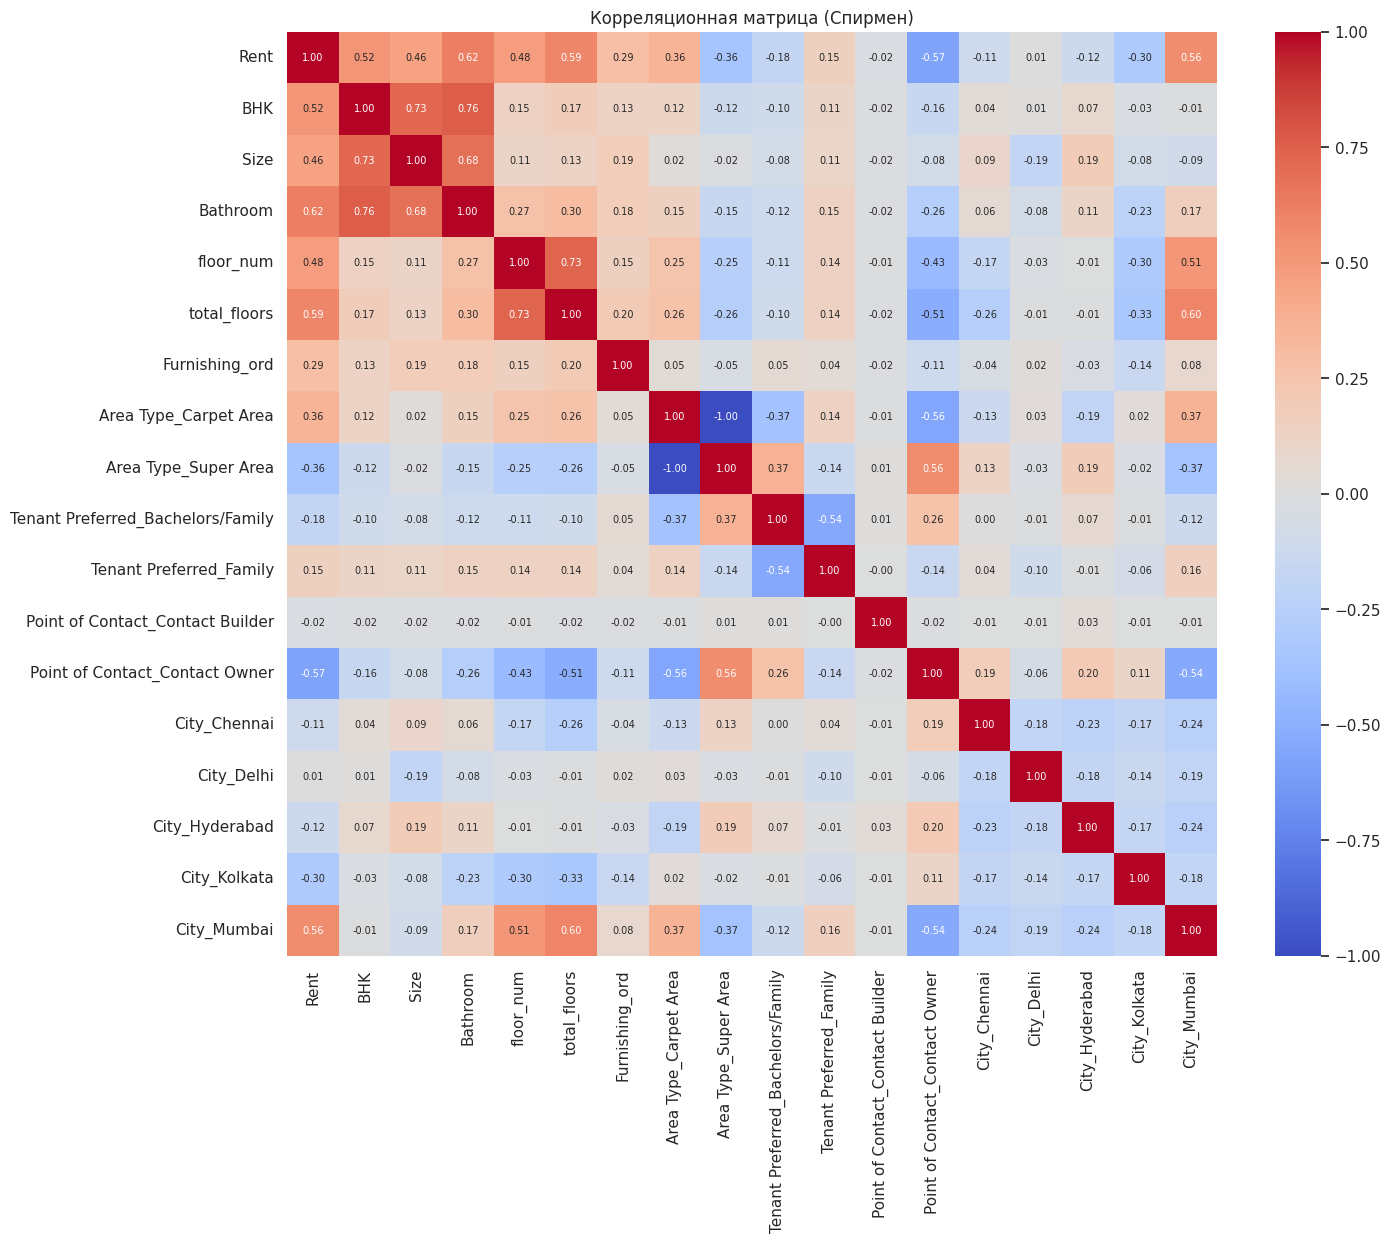

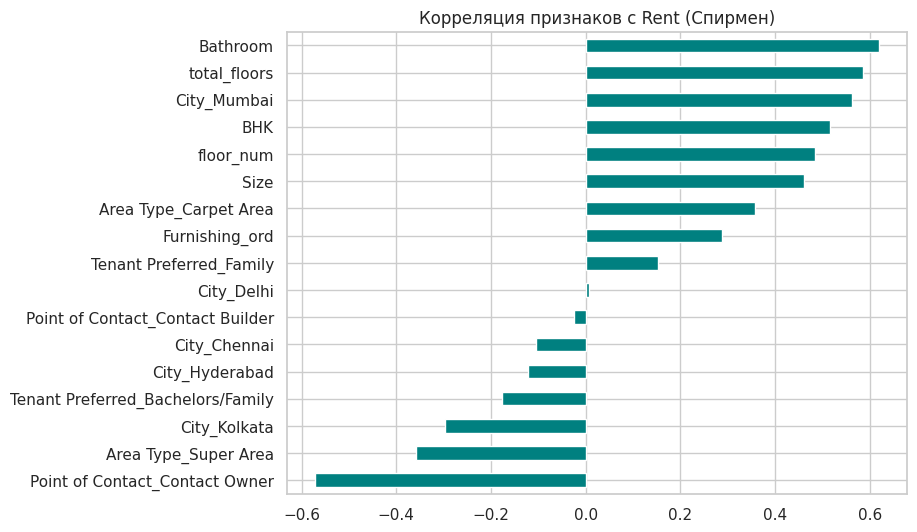

In [23]:
# Rent не нормален, есть дискретные и порядковый признаки -> используем корреляцию Спирмена
corr = df_model.corr(method='spearman')
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Корреляционная матрица (Спирмен)')
plt.show()

corr_target = corr['Rent'].drop('Rent')
plt.figure(figsize=(8, 6))
corr_target.sort_values().plot(kind='barh', color='teal')
plt.title('Корреляция признаков с Rent (Спирмен)')
plt.show()

**Интерпретация корреляционной матрицы** (использован коэффициент Спирмена: `Rent` не нормален, есть дискретные и порядковый признаки, поэтому важна монотонная связь):
- Положительно связаны с арендой: `Bathroom` (ρ = 0.62), `total_floors` (0.59), `City_Mumbai` (0.56), `BHK` (0.52), `floor_num` (0.48), `Size` (0.46), `Furnishing_ord` (0.29).
- Отрицательно связаны с арендой: `Point of Contact_Contact Owner` (-0.57: объявления собственников дешевле), `City_Kolkata` (-0.30).
- `City_Delhi` (ρ ≈ 0.01) практически не связан с арендой.
- Столбцы `Area Type_Carpet Area` и `Area Type_Super Area` почти зеркальны (ρ ≈ ±0.36), так как это две основные категории одного признака.
- Между самими предикторами `BHK`, `Bathroom` и `Size` ожидаемо видна положительная связь (больше комнат - больше ванных и площади), поэтому в модели возможна частичная мультиколлинеарность.

In [24]:
top5 = corr_target.abs().sort_values(ascending=False).head(5)
top5_features = list(top5.index)
pd.DataFrame({'Признак': top5_features, 'rho (Спирмен)': corr_target[top5_features].values, '|rho|': top5.values})

,Признак,rho (Спирмен),|rho|
0,Bathroom,0.620,0.620
1,total_floors,0.586,0.586
2,Point of Contact_Contact Owner,-0.571,0.571
3,City_Mumbai,0.562,0.562
4,BHK,0.516,0.516


**Топ-5 признаков с самой сильной связью с `Rent`** (по модулю ρ Спирмена):
1. `Bathroom` (ρ = 0.620)
2. `total_floors` (ρ = 0.586)
3. `Point of Contact_Contact Owner` (ρ = -0.571)
4. `City_Mumbai` (ρ = 0.562)
5. `BHK` (ρ = 0.516)

Именно эти пять признаков используются в регрессионной модели. `Size` в топ-5 не вошёл (ρ = 0.46), но он тесно связан с `BHK` и `Bathroom`.

## Масштабирование данных

In [25]:
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[quant_cols] = scaler.fit_transform(df_model[quant_cols])

print('Среднее и стандартное отклонение до масштабирования (нужны для интерпретации):')
display(pd.DataFrame({'mean': scaler.mean_, 'std': scaler.scale_}, index=quant_cols))
print('Проверка после масштабирования (mean ~ 0, std ~ 1):')
display(df_scaled[quant_cols].agg(['mean', 'std']).round(3))

Среднее и стандартное отклонение до масштабирования (нужны для интерпретации):


,mean,std
BHK,2.004,0.751
Size,872.626,441.604
Bathroom,1.868,0.750
floor_num,3.239,5.295
total_floors,6.621,8.718


Проверка после масштабирования (mean ~ 0, std ~ 1):


,BHK,Size,Bathroom,floor_num,total_floors
mean,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000


Пять количественных предикторов (`BHK`, `Size`, `Bathroom`, `floor_num`, `total_floors`) нормализованы с помощью `StandardScaler()`: $z = (x - \bar{x}) / s$. После преобразования среднее каждого признака равно 0, стандартное отклонение - 1. Результат - таблица `df_scaled`.

- Бинарные One-Hot-столбцы и порядковый `Furnishing_ord` не масштабируются.
- Целевой признак `Rent` оставлен в исходных рупиях, чтобы коэффициенты и метрики интерпретировались в понятных единицах (₹).
- Масштабирование выполнено до разбиения выборки, как требует задание. Строго говоря, масштабатор лучше обучать только на тренировочной части, чтобы не было утечки информации, но при 4517 наблюдениях влияние пренебрежимо мало.

## Регрессия

**Описание модели:** мы хотим построить модель множественной линейной регрессии, которая предсказывает ежемесячную арендную плату жилья (`Rent`, ₹) на основании пяти наиболее связанных с ней признаков: количества ванных комнат (`Bathroom`), этажности дома (`total_floors`), количества спален (`BHK`), того, что объявление размещено собственником (`Point of Contact_Contact Owner`), и того, что жильё находится в Mumbai (`City_Mumbai`). Количественные предикторы использованы в масштабированном виде.

Выборка (масштабированные данные) разделена на тренировочную (80%, 3613 наблюдений) и тестовую (20%, 904 наблюдения), `random_state = 42`.

In [26]:
X = df_scaled[top5_features]
y = df_scaled['Rent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (3613, 5)  Test: (904, 5)


In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

params = pd.DataFrame({'Признак': ['Intercept'] + top5_features,
                       'Коэффициент': [model.intercept_] + list(model.coef_)})
display(params)

eq = f'Rent = {model.intercept_:,.2f}'
for name, b in zip(top5_features, model.coef_):
    eq += f' {"+" if b >= 0 else "-"} {abs(b):,.2f}*[{name}]'
print(eq)

,Признак,Коэффициент
0,Intercept,"28,703.541"
1,Bathroom,"7,858.254"
2,total_floors,"6,353.102"
3,Point of Contact_Contact Owner,"-10,736.417"
4,City_Mumbai,"28,601.908"
5,BHK,"6,094.061"


Rent = 28,703.54 + 7,858.25*[Bathroom] + 6,353.10*[total_floors] - 10,736.42*[Point of Contact_Contact Owner] + 28,601.91*[City_Mumbai] + 6,094.06*[BHK]


**Уравнение обученной модели** (индекс $z$ обозначает стандартизованный признак; `Owner` и `Mumbai` - бинарные признаки):

$$\widehat{Rent} = 28\,703.54 + 7\,858.25 \cdot Bathroom_z + 6\,353.10 \cdot TotalFloors_z + 6\,094.06 \cdot BHK_z - 10\,736.42 \cdot Owner + 28\,601.91 \cdot Mumbai$$

**Интерпретация параметров модели** (при прочих равных условиях; стандартные отклонения: `Bathroom` ≈ 0.75 ванной, `total_floors` ≈ 8.7 этажа, `BHK` ≈ 0.75 комнаты):
- **Intercept = 28 703.54**: прогнозируемая аренда для объявления агента (не собственника) не в Mumbai со средним количеством ванных, спален и средней этажностью дома (все масштабированные признаки равны 0).
- **Bathroom = 7 858.25**: при увеличении числа ванных на 1 стандартное отклонение (≈ 0.75 ванной) аренда растёт в среднем на 7 858 ₹.
- **total_floors = 6 353.10**: при увеличении этажности дома на 1 стандартное отклонение (≈ 8.7 этажа) аренда растёт в среднем на 6 353 ₹ (высотные дома дороже).
- **BHK = 6 094.06**: при увеличении числа спален на 1 стандартное отклонение (≈ 0.75 комнаты) аренда растёт в среднем на 6 094 ₹.
- **Point of Contact_Contact Owner = -10 736.42**: объявления собственников в среднем на 10 736 ₹ дешевле объявлений агентов (и застройщика) при прочих равных.
- **City_Mumbai = 28 601.91**: жильё в Mumbai в среднем на 28 602 ₹ дороже, чем в других городах, при прочих равных - самый сильный эффект в модели.

In [28]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

metrics = pd.DataFrame({'Метрика': ['MAE', 'MSE', 'RMSE', 'R2', 'MAPE, %'],
                        'Тест': [mae, mse, rmse, r2, mape]})
display(metrics)
print(f'R2 на train: {r2_score(y_train, y_pred_train):.3f}  |  R2 на test: {r2:.3f}')
print(f'Средняя Rent в тесте: {y_test.mean():,.0f}')

,Метрика,Тест
0,MAE,"12,427.221"
1,MSE,"387,563,450.672"
2,RMSE,"19,686.631"
3,R2,0.587
4,"MAPE, %",72.424


R2 на train: 0.613  |  R2 на test: 0.587
Средняя Rent в тесте: 25,568


**Интерпретация метрик качества на тестовой выборке:**
- **MAE = 12 427 ₹**: в среднем модель ошибается на 12 427 ₹ по модулю, это около половины средней аренды в тесте (25 568 ₹).
- **MSE = 3.88·10⁸ ₹²**: средний квадрат ошибки (в квадратах единиц, поэтому для наглядности используют его корень - RMSE).
- **RMSE = 19 687 ₹**: типичная ошибка прогноза с усиленным весом больших ошибок. RMSE заметно больше MAE - в данных есть наблюдения (дорогое жильё), на которых модель ошибается сильно.
- **R² = 0.587**: модель объясняет около 58.7% дисперсии арендной платы на тестовой выборке; остальные ~41% объясняются факторами вне модели (площадь, меблировка, район и др.).
- **MAPE = 72.4%**: в относительном выражении ошибка велика, особенно для дешёвых объявлений.
- R² на обучающей (0.613) и тестовой (0.587) выборках близки - сильного переобучения нет.

**Вывод:** модель имеет умеренное качество и подходит для общей оценки уровня аренды, но не для точного прогноза. Улучшить её можно, например, логарифмированием `Rent`, добавлением `Size`, `Furnishing_ord` и остальных городов.

## Тестирование гипотез

Уровень значимости во всех тестах $\alpha = 0.05$. Изученные тесты: Z-тест для среднего, t-тест для среднего, χ²-тест для дисперсии, Z-тест для двух средних, F-тест для дисперсий, t-тест Стьюдента (равные дисперсии), t-тест Уэлча (неравные дисперсии), Z-тест для доли, парный t-тест; перед ними проверяется нормальность тестом Шапиро-Уилка.

Генеральной совокупностью считаем `df_iqr`; для тестов берутся случайные выборки по 200 наблюдений (`random_state` зафиксирован).

### Тест Шапиро-Уилка (проверка нормальности)
Словесная формулировка: проверим, распределены ли `Rent`, `log(Rent)` и `Size` нормально.

- $H_0$: выборка получена из нормально распределённой генеральной совокупности
- $H_1$: распределение отличается от нормального

In [29]:
alpha = 0.05
for name, x in [('Rent', df_iqr['Rent']), ('log(Rent)', np.log(df_iqr['Rent'])), ('Size', df_iqr['Size'])]:
    W, p = stats.shapiro(x)
    print(f'{name:10s} W = {W:.4f}, p-value = {p:.2e} -> {"нормальность не отвергается" if p > alpha else "нормальность отвергается"}')

Rent       W = 0.6061, p-value = 9.63e-73 -> нормальность отвергается
log(Rent)  W = 0.9648, p-value = 7.90e-32 -> нормальность отвергается
Size       W = 0.9744, p-value = 9.59e-28 -> нормальность отвергается


**Интерпретация:** для всех трёх величин p-value намного меньше 0.05, нормальность отвергается (даже для `log(Rent)`: W = 0.965). Следовательно, строгих условий нормальности нет. Для тестов о средних это не критично, так как объём выборок n = 200 достаточно велик и работает центральная предельная теорема. Для тестов о дисперсиях (χ², F) нарушение нормальности - серьёзная проблема, поэтому их результаты проверяются дополнительными методами и считаются приблизительными.

In [30]:
# Выборки для тестов (генеральная совокупность = df_iqr)
n = 200
rent_all = df_iqr['Rent']
sample = rent_all.sample(n=n, random_state=42)
sigma_pop = rent_all.std(ddof=0)       # "известное" стандартное отклонение генеральной совокупности
print(f'Выборка: n = {n}, среднее = {sample.mean():,.1f}, std = {sample.std():,.1f}')
print(f'Генеральное sigma = {sigma_pop:,.1f}')

Выборка: n = 200, среднее = 26,087.0, std = 32,355.0
Генеральное sigma = 32,607.8


### Тест 1. Z-тест для среднего (дисперсия известна)
**Словесная формулировка:** мы хотим проверить гипотезу о том, что средняя арендная плата равна 25 000 ₹, если считать, что стандартное отклонение выборки равно стандартному отклонению генеральной совокупности ($\sigma = 32\,607.8$).

- $H_0: \mu = 25\,000$
- $H_1: \mu \neq 25\,000$

Предпосылки: выборка случайная, $\sigma$ известна, n = 200 достаточно для применения ЦПТ.

In [31]:
mu0 = 25000
z = (sample.mean() - mu0) / (sigma_pop / np.sqrt(n))
p_z = 2 * (1 - stats.norm.cdf(abs(z)))
print(f'z = {z:.3f}, p-value = {p_z:.4f}')
print('Решение:', 'H0 отвергается' if p_z < alpha else 'H0 не отвергается', f'(alpha = {alpha})')

z = 0.471, p-value = 0.6373
Решение: H0 не отвергается (alpha = 0.05)


**Интерпретация:** выборочное среднее равно 26 087 ₹, z = 0.471, p-value = 0.637 > 0.05, поэтому $H_0$ **не отвергается**. Данные не противоречат тому, что средняя аренда равна 25 000 ₹ (это не доказывает равенство, а лишь означает, что оснований его отвергнуть нет).

### Тест 2. t-тест для среднего (дисперсия неизвестна)
**Словесная формулировка:** мы хотим проверить гипотезу о том, что средняя арендная плата превышает 20 000 ₹, если дисперсия генеральной совокупности неизвестна и оценивается по выборке.

- $H_0: \mu = 20\,000$
- $H_1: \mu > 20\,000$

Предпосылки: случайная выборка, независимые наблюдения, n = 200 (ЦПТ), хотя распределение `Rent` скошено.

In [32]:
mu0 = 20000
t_stat, p_t = stats.ttest_1samp(sample, popmean=mu0, alternative='greater')
print(f't = {t_stat:.3f}, p-value = {p_t:.4f}')
print('Решение:', 'H0 отвергается' if p_t < alpha else 'H0 не отвергается', f'(alpha = {alpha})')

t = 2.661, p-value = 0.0042
Решение: H0 отвергается (alpha = 0.05)


**Интерпретация:** t = 2.661, p-value = 0.004 < 0.05, поэтому $H_0$ **отвергается** в пользу $H_1$: средняя арендная плата статистически значимо выше 20 000 ₹.

### Тест 3. χ²-тест для дисперсии
**Словесная формулировка:** мы хотим проверить гипотезу о том, что стандартное отклонение арендной платы равно 30 000 ₹ (дисперсия равна $30\,000^2$).

- $H_0: \sigma^2 = 30\,000^2$
- $H_1: \sigma^2 \neq 30\,000^2$

Статистика: $\chi^2 = \frac{(n-1)s^2}{\sigma_0^2}$, при $H_0$ имеет распределение $\chi^2_{n-1}$. Предпосылка: нормальность данных - **нарушена** (см. Шапиро-Уилка), поэтому результат приблизителен.

In [33]:
sigma0 = 30000
s2 = sample.var(ddof=1)
chi2 = (n - 1) * s2 / sigma0 ** 2
p_chi = 2 * min(stats.chi2.cdf(chi2, n - 1), stats.chi2.sf(chi2, n - 1))
print(f's^2 = {s2:,.0f}, chi2 = {chi2:.2f}, df = {n - 1}, p-value = {p_chi:.4f}')
print('Решение:', 'H0 отвергается' if p_chi < alpha else 'H0 не отвергается', f'(alpha = {alpha})')

s^2 = 1,046,843,750, chi2 = 231.47, df = 199, p-value = 0.1142
Решение: H0 не отвергается (alpha = 0.05)


**Интерпретация:** $\chi^2 = 231.47$ при 199 степенях свободы, p-value = 0.114 > 0.05, поэтому $H_0$ **не отвергается**: выборочная дисперсия не противоречит значению $30\,000^2$. Из-за нарушения нормальности вывод следует считать ориентировочным.

In [34]:
# Группы для сравнения
F_all = df_iqr.loc[df_iqr['Furnishing Status'] == 'Furnished', 'Rent']
U_all = df_iqr.loc[df_iqr['Furnishing Status'] == 'Unfurnished', 'Rent']
B_all = df_iqr.loc[df_iqr['City'] == 'Bangalore', 'Rent']
C_all = df_iqr.loc[df_iqr['City'] == 'Chennai', 'Rent']

F_s, U_s = F_all.sample(n, random_state=1), U_all.sample(n, random_state=1)
B_s, C_s = B_all.sample(n, random_state=1), C_all.sample(n, random_state=1)

pd.DataFrame({'mean': [F_s.mean(), U_s.mean(), B_s.mean(), C_s.mean()],
              'var': [F_s.var(), U_s.var(), B_s.var(), C_s.var()]},
             index=['Furnished', 'Unfurnished', 'Bangalore', 'Chennai'])

,mean,var
Furnished,"43,324.990","2,074,044,715.085"
Unfurnished,"21,110.995","525,115,768.960"
Bangalore,"15,844.000","126,279,863.317"
Chennai,"17,757.605","167,006,028.461"


### Тест 4. Z-тест для двух средних (дисперсии известны)
**Словесная формулировка:** мы хотим проверить гипотезу о том, что средняя аренда полностью меблированного жилья (Furnished) выше, чем немеблированного (Unfurnished), если считать известными дисперсии групп (берём их по всей генеральной совокупности каждой группы).

- $H_0: \mu_{F} = \mu_{U}$
- $H_1: \mu_{F} > \mu_{U}$

Выборки независимы, по 200 наблюдений в каждой.

In [35]:
# Дисперсии групп считаем известными (берем по всей генеральной совокупности группы)
var1, var2 = F_all.var(ddof=0), U_all.var(ddof=0)
z2 = (F_s.mean() - U_s.mean()) / np.sqrt(var1 / n + var2 / n)
p_z2 = 1 - stats.norm.cdf(z2)           # H1: mu_F > mu_U
print(f'z = {z2:.3f}, p-value = {p_z2:.2e}')
print('Решение:', 'H0 отвергается' if p_z2 < alpha else 'H0 не отвергается', f'(alpha = {alpha})')

z = 6.063, p-value = 6.66e-10
Решение: H0 отвергается (alpha = 0.05)


**Интерпретация:** средняя аренда в выборках - 43 325 ₹ (Furnished) и 21 111 ₹ (Unfurnished), z = 6.063, p-value ≈ 7·10⁻¹⁰ < 0.05, поэтому $H_0$ **отвергается**: полностью меблированное жильё в среднем значимо дороже немеблированного.

### Тест 5. F-тест о равенстве дисперсий
**Словесная формулировка:** мы хотим проверить гипотезу о том, что дисперсии арендной платы равны (a) в Bangalore и Chennai и (b) у меблированного и немеблированного жилья. Результат нужен, чтобы выбрать между тестом Стьюдента и тестом Уэлча.

- $H_0: \sigma_1^2 = \sigma_2^2$
- $H_1: \sigma_1^2 \neq \sigma_2^2$

Статистика: $F = s_1^2 / s_2^2$, распределение $F_{n_1-1,\,n_2-1}$. F-тест чувствителен к нарушению нормальности, поэтому дополнительно использован тест Левена.

In [36]:
def f_test(a, b):
    F = a.var(ddof=1) / b.var(ddof=1)
    dfa, dfb = len(a) - 1, len(b) - 1
    p = 2 * min(stats.f.cdf(F, dfa, dfb), stats.f.sf(F, dfa, dfb))
    return F, p

for name, (a, b) in {'Bangalore vs Chennai': (B_s, C_s), 'Furnished vs Unfurnished': (F_s, U_s)}.items():
    F, p = f_test(a, b)
    print(f'{name:26s} F = {F:.3f}, p-value = {p:.4g} -> {"H0 отвергается" if p < alpha else "H0 не отвергается"}')
    # F-тест чувствителен к отклонению от нормальности, поэтому дополнительно проверяем тестом Левена
    W, pl = stats.levene(a, b)
    print(f'{"":26s} Левен: W = {W:.3f}, p-value = {pl:.4g}')

Bangalore vs Chennai       F = 0.756, p-value = 0.0493 -> H0 отвергается
                           Левен: W = 1.446, p-value = 0.2299
Furnished vs Unfurnished   F = 3.950, p-value = 1.035e-20 -> H0 отвергается
                           Левен: W = 27.971, p-value = 2.037e-07


**Интерпретация:**
- Bangalore и Chennai: F = 0.756, p-value = 0.049 - $H_0$ отвергается лишь на границе уровня 5%. Тест Левена (устойчив к ненормальности) даёт p-value = 0.230, $H_0$ не отвергается. Различие дисперсий - пограничное и практически несущественное, дисперсии можно считать близкими.
- Furnished и Unfurnished: F = 3.95, p-value ≈ 10⁻²⁰ (Левен: ≈ 2·10⁻⁷) - $H_0$ **отвергается**: дисперсии существенно различаются, значит, для этой пары тест Стьюдента неприменим и нужен тест Уэлча.

### Тест 6. t-тест Стьюдента (равные дисперсии)
**Словесная формулировка:** мы хотим проверить гипотезу о том, что средняя арендная плата в Bangalore и Chennai одинакова, если считать дисперсии в двух городах равными.

- $H_0: \mu_{B} = \mu_{C}$
- $H_1: \mu_{B} \neq \mu_{C}$

Предпосылки: независимые выборки (по 200), примерное равенство дисперсий (тест Левена это допускает, F-тест - на границе), ЦПТ.

In [37]:
t_s, p_s = stats.ttest_ind(B_s, C_s, equal_var=True)
print(f'Стьюдент: t = {t_s:.3f}, p-value = {p_s:.4f}')
print('Решение:', 'H0 отвергается' if p_s < alpha else 'H0 не отвергается', f'(alpha = {alpha})')
# Проверка устойчивости вывода: тот же тест без предположения о равенстве дисперсий
t_s2, p_s2 = stats.ttest_ind(B_s, C_s, equal_var=False)
print(f'Для сравнения, Уэлч: t = {t_s2:.3f}, p-value = {p_s2:.4f}')

Стьюдент: t = -1.580, p-value = 0.1148
Решение: H0 не отвергается (alpha = 0.05)
Для сравнения, Уэлч: t = -1.580, p-value = 0.1149


**Интерпретация:** средняя аренда в выборках - 15 844 ₹ (Bangalore) и 17 758 ₹ (Chennai), t = -1.580, p-value = 0.115 > 0.05, поэтому $H_0$ **не отвергается**: статистически значимого различия средней аренды между городами нет. Поскольку F-тест был пограничным, тест повторён в форме Уэлча (без допущения о равенстве дисперсий): результат тот же (p-value = 0.115), вывод устойчив.

### Тест 7. t-тест Уэлча (неравные дисперсии)
**Словесная формулировка:** мы хотим проверить гипотезу о том, что средняя аренда меблированного жилья выше, чем немеблированного, если дисперсии групп неизвестны и, как показал F-тест, не равны.

- $H_0: \mu_{F} = \mu_{U}$
- $H_1: \mu_{F} > \mu_{U}$

Предпосылки: независимые выборки, ЦПТ (n = 200 в каждой); равенство дисперсий не требуется.

In [38]:
t_w, p_w = stats.ttest_ind(F_s, U_s, equal_var=False, alternative='greater')
print(f't = {t_w:.3f}, p-value = {p_w:.2e}')
print('Решение:', 'H0 отвергается' if p_w < alpha else 'H0 не отвергается', f'(alpha = {alpha})')
# Проверка устойчивости: непараметрический тест Манна-Уитни (не требует нормальности)
u, p_u = stats.mannwhitneyu(F_s, U_s, alternative='greater')
print(f'Для сравнения, Манн-Уитни: U = {u:.0f}, p-value = {p_u:.2e}')

t = 6.162, p-value = 1.18e-09
Решение: H0 отвергается (alpha = 0.05)
Для сравнения, Манн-Уитни: U = 28364, p-value = 2.30e-13


**Интерпретация:** t = 6.162, p-value ≈ 1.2·10⁻⁹ < 0.05, поэтому $H_0$ **отвергается**: меблированное жильё статистически значимо дороже. Непараметрический тест Манна-Уитни (не требует нормальности) даёт тот же вывод (p-value ≈ 2·10⁻¹³), то есть результат устойчив к нарушению нормальности.

### Тест 8. Z-тест для доли
**Словесная формулировка:** мы хотим проверить гипотезу о том, что доля объявлений, размещённых собственниками (Contact Owner), равна 75%.

- $H_0: p = 0.75$
- $H_1: p \neq 0.75$

Статистика: $z = \frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}$. Предпосылки: независимые наблюдения, $np_0 \ge 10$ и $n(1-p_0) \ge 10$ - выполнены (n = 4517).

In [39]:
p0 = 0.75
count = (df_iqr['Point of Contact'] == 'Contact Owner').sum()
nobs = len(df_iqr)
p_hat = count / nobs
z_p = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / nobs)
p_zp = 2 * (1 - stats.norm.cdf(abs(z_p)))
print(f'Контактов с владельцем: {count} из {nobs}, доля = {p_hat:.4f}')
print(f'Проверка np0 = {nobs * p0:.0f} >= 10 и n(1-p0) = {nobs * (1 - p0):.0f} >= 10')
print(f'z = {z_p:.3f}, p-value = {p_zp:.2e}')
print('Решение:', 'H0 отвергается' if p_zp < alpha else 'H0 не отвергается', f'(alpha = {alpha})')

Контактов с владельцем: 3165 из 4517, доля = 0.7007
Проверка np0 = 3388 >= 10 и n(1-p0) = 1129 >= 10
z = -7.654, p-value = 1.95e-14
Решение: H0 отвергается (alpha = 0.05)


**Интерпретация:** выборочная доля $\hat{p} = 0.7007$, z = -7.654, p-value ≈ 2·10⁻¹⁴ < 0.05, поэтому $H_0$ **отвергается**: доля объявлений собственников статистически значимо отличается от 75% (она ниже). При большом объёме выборки значимыми становятся и небольшие отличия, на практике разница составляет около 5 процентных пунктов.

### Тест 9. Парный t-тест - не применим
Парный t-тест требует **зависимых выборок**: двух измерений одного и того же признака для одних и тех же объектов (например, аренда одной квартиры до и после ремонта). В нашем датасете каждая строка - отдельное объявление, парных измерений нет, а разные признаки (`Rent`, `Size`, `BHK`) измеряются в разных единицах и не сопоставимы. Поэтому парный t-тест применять нельзя.

## Общие выводы

- Арендная плата в данных сильно скошена вправо: медиана 15 000 ₹, среднее около 26 700 ₹, есть небольшое число очень дорогих объявлений.
- Самый сильный фактор - город: жильё в Mumbai в среднем на ~28 600 ₹ дороже (при прочих равных). Также аренду повышают количество ванных, спален, этажность дома и меблировка; объявления собственников дешевле объявлений агентов.
- Линейная регрессия на 5 наиболее связанных признаках объясняет 58.7% дисперсии аренды на тесте (RMSE ≈ 19 700 ₹), без заметного переобучения.
- Гипотезы подтвердили, что меблированное жильё значимо дороже немеблированного, а средняя аренда превышает 20 000 ₹; между Bangalore и Chennai значимого различия в средней аренде нет.